In [2]:
# directional distribution - south side

In [20]:
import pandas as pd
import geopandas as gpd
import shapely
from shapely.geometry import Point
from cartopy import crs
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import re
from shapely.wkt import loads
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
import altair as alt
from scipy import ndimage
from PIL import Image

In [4]:
commarea = gpd.read_file('south_chicago.geojson')
commarea.geometry = commarea.geometry.to_crs(epsg=4326)

In [5]:
hom_1940 = gpd.read_file('homcide-locations_1940-1964.csv')
hom_1940.POINT_X = hom_1940.POINT_X.astype(float)
hom_1940.POINT_Y = hom_1940.POINT_Y.astype(float)
hom_1940['geometry'] = hom_1940.apply(lambda x: Point(x.POINT_X, x.POINT_Y),
                                      axis=1)
hom_1940 = gpd.GeoDataFrame(hom_1940, geometry='geometry', crs='EPSG:4326')
hom_1940.year = hom_1940.year.astype(float).astype(int)
print(type(hom_1940))

<class 'geopandas.geodataframe.GeoDataFrame'>


In [6]:
hom_1940.head()

,address_id,geo_strat,batch,file_name,page,case_no,dupe_id,date,home_addr,died_addr,...,clean_note,verd_note,news_links,id,year,month,verdict2,POINT_X,POINT_Y,geometry
0,1.000000000000000,gaps street lines,4.000000000000000,1940_02-06_VOL 1,306,86,,1940-05-23,1018 Polk St,1300 S Peoria St,...,"1300 S Peoria does not exist anymore, closest ...",,,1.000000000000000,1940,5.000000000000000,MURDER,-87.648924,41.865128,POINT (-87.64892 41.86513)
1,2.000000000000000,census geocoder,1.000000000000000,1941_01_VOL 1,40,21,,1941-01-01,3520 Rhodes Ave,Bridewell Hospital,...,,,,2.000000000000000,1941,1.000000000000000,JUSTIFIABLE HOMICIDE,-87.614397,41.830600,POINT (-87.6144 41.8306)
2,3.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,45,26,,1940-02-07,,Alley East of Clark-South of Grand Ave,...,"""IDENTIFY SLAIN BANDIT AS INSANE ASYLUM FUGITI...",,,3.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.630068,41.891584,POINT (-87.63007 41.89158)
3,4.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,55,43,,1940-02-11,2000 Walnut St,2055 Lake St,...,,,,4.000000000000000,1940,2.000000000000000,JUSTIFIABLE HOMICIDE,-87.678073,41.884878,POINT (-87.67807 41.88488)
4,5.000000000000000,census geocoder,4.000000000000000,1940_02-06_VOL 1,57,46,,1940-02-12,1414 So Peoria St,,...,CCH,,,5.000000000000000,1940,2.000000000000000,MURDER,-87.648914,41.862169,POINT (-87.64891 41.86217)


In [7]:
hom_1940_south = gpd.sjoin(hom_1940, commarea, how='inner')
hom_1940_south.geometry.head()

1      POINT (-87.6144 41.8306)
5    POINT (-87.63078 41.80449)
7    POINT (-87.62195 41.84083)
8    POINT (-87.63161 41.83533)
9    POINT (-87.62779 41.82898)
Name: geometry, dtype: geometry

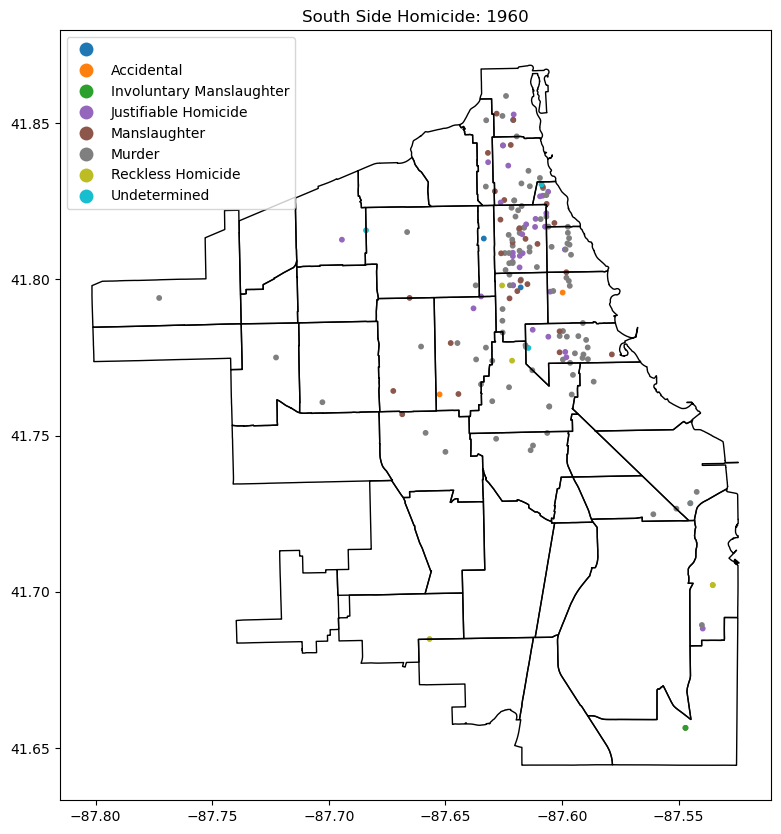

In [8]:
x=1960

fig, ax = plt.subplots(figsize=(10, 10))

hom_1940_south[hom_1940_south.year==x].plot(column='verdict', markersize=10, legend=True, ax=ax)

commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

plt.title(f'South Side Homicide: {x}')

plt.show()

In [9]:
def plot_directional_ellipse_gdf(gdf, ax=None, n_std=2.0, **kwargs):
    """
    Plot a directional (covariance-based) ellipse from a GeoDataFrame of Points.
    
    Parameters:
    - gdf: GeoDataFrame with Point geometries
    - ax: matplotlib axis (optional)
    - n_std: Number of standard deviations (e.g., 1, 2, 3)
    - kwargs: passed to matplotlib.patches.Ellipse (e.g., edgecolor, facecolor)
    """
    if ax is None:
        fig, ax = plt.subplots()

    # Extract coordinates from geometry
    coords = np.array([[geom.x, geom.y] for geom in gdf.geometry if geom is not None])

    if len(coords) < 2:
        raise ValueError("Need at least two valid Point geometries to compute an ellipse.")

    # Compute mean and covariance
    mean = coords.mean(axis=0)
    cov = np.cov(coords, rowvar=False)

    # Eigen-decomposition of covariance matrix
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(vals)
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))

    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)

    # Plot the points and ellipse
    gdf.plot(ax=ax, color='black', markersize=5)
    ax.set_aspect('equal')
    return ax

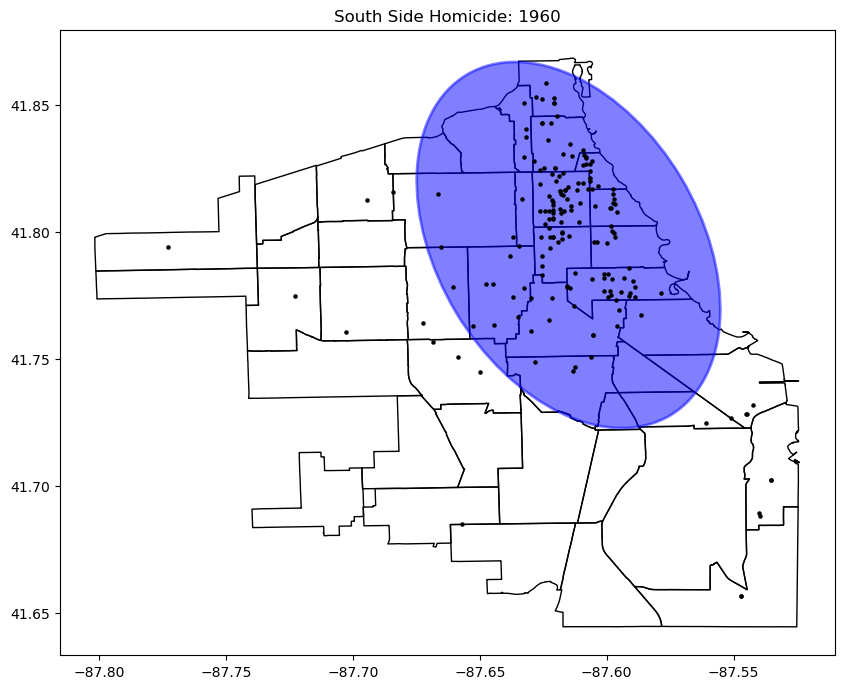

In [10]:
x=1960

fig, ax = plt.subplots(figsize=(10, 10))
commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

plt.title(f'South Side Homicide: {x}')

plot_directional_ellipse_gdf(hom_1940_south[hom_1940_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
plt.show()

In [11]:
hom_1940_south.year.values

array([1941, 1940, 1940, ..., 1962, 1962, 1962], shape=(3762,))

In [12]:
plt.close()

In [18]:
print(sorted(hom_1940_south.year.unique()))

[np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1945), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1949), np.int64(1950), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964)]


In [25]:
file_names = []

for i in sorted(hom_1940_south.year.unique()):

    x=i

    fig, ax = plt.subplots(figsize=(10, 10))
    plt.ylim(41.63, 41.90)
    commarea.plot(facecolor="none", edgecolor="black", linewidth=1, ax=ax)

    plt.title(f'South Side Homicide: {x}')

    plot_directional_ellipse_gdf(hom_1940_south[hom_1940_south['year']==x], n_std=2, ax=ax, edgecolor='blue', facecolor='blue', linewidth=2, alpha=0.50)
    plt.savefig(f'dir_dist/dist_{x}.png')
    file_names.append(f'dir_dist/dist_{x}.png')
    print(file_names)
    plt.close()

['dir_dist/dist_1940.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png', 'dir_dist/dist_1946.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'dir_dist/dist_1942.png', 'dir_dist/dist_1943.png', 'dir_dist/dist_1944.png', 'dir_dist/dist_1945.png', 'dir_dist/dist_1946.png', 'dir_dist/dist_1947.png']
['dir_dist/dist_1940.png', 'dir_dist/dist_1941.png', 'di

In [26]:
def create_gif(file_names, gif_name, frame_duration=200):
    """
        Creates a GIF from images in a folder.
    
        Parameters:
        file_names: list of image paths
        gif_name (str): path of the output GIF file (e.g., "animation.gif").
        frame_duration (int): Duration of each frame in milliseconds.
    """
    images = []
    
        # Sort files to ensure correct order
    file_names.sort()
        
    for filename in file_names:
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                img = Image.open(filename)
                images.append(img)
            except Exception as e:
                print(f"Error opening image {filename}: {e}")
    
    if images:
        images[0].save(gif_name, save_all=True, append_images=images[1:], 
                          duration=frame_duration, loop=0)
        print(f"GIF saved as {gif_name} in {gif_name}")
    else:
        print("No valid images found in the specified folder.")

In [27]:
create_gif(file_names, 'dir_dist/1940_1964.gif')

GIF saved as dir_dist/1940_1964.gif in dir_dist/1940_1964.gif
